## Exercise II: Monte Carlo Integration and Importance Sampling [Total: 15 Marks]

Consider the integral

\begin{equation}
    I = \int_0^1 \sin(\pi x(1-x))\mathrm{d}x = \mathbb{E}[X], \quad X=g(U), \quad g(U)=\sin(\pi U(1-U))
\end{equation}

where $U$ is a uniform random variable in $(0,1)$.



1.   Use Monte Carlo integration based on sampling $U$ to estimate $I$ with $1\sigma$ error at most $0.001$. How many samples do you need? (It is not necessary to automate this: trial and error is sufficient.) **[5 Marks]**
2.   Choose a random variable $Z$ on $(0,1)$ whose density resembles the integrand of $I$ and which you know how to sample efficiently (by inversion method, acceptance-rejection, or a built-in Python function). Estimate $I$ again using importance sampling, i.e. $I = \mathbb{E}[X']$ where $X' = g(Z) f_U(Z)/f_Z(Z)$, with an error of at most 0.001. How many samples did you need this time? Comment on the result. **[10 Marks]**


In [1]:
# all packages and helper functions (not the directly answering the main question) can be found in helper_functions_1_2_3.py:
from helper_functions_1_2_3 import *
from ploting_functions import *

# 2.1

The monte carlo estimator for $I=\int_{0}^1g(s)ds$ is given as
$$
I_n = \frac{1}{n}\sum_{i=1}^nX_i=\frac{1}{n}\sum_{i=1}^ng(U_i)
$$

Where $X_i=g(U_i)=\sin\big(\pi U_i (1-U_i)\big)$ and $U_1,...,U_n$ are i.i.d. random variabless from the $ \text{Uniform}(0,1)$ distribution. $I_n$ is an unbiased estimator of $I$ and the variance and standard deviation is given as 
$$
Var(I_n)= \frac{1}{n^2}\sum_{i=1}^n Var(X_i)=\frac{1}{n}Var(X) \\
\Rightarrow std(I_n) = \frac{1}{\sqrt{n}}std(X)
$$

We increase the number of samples $n$ and track both the estimate and standard deviation of the estimate. To minimize noise from randomness, we only draw $U_1,...,U_n$ once and then gradually incrase the index to incldue more observaitons. 

In [6]:
N= 100_000
U = rng.uniform(size=(N,1))

def g_fct(sample):
    return np.sin(np.pi*sample*(1-sample))
def MC_est(sample):
    '''The monte carlo estimate and standard error'''
    return np.mean(sample,axis=0), np.std(sample, axis=0, ddof=1)/np.sqrt(len(sample))

step = int(N/100)
x_axis = list(range(step,N,step))
std_list = []
trans = g_fct(U)
for i in x_axis:
    std_list.append(MC_est(trans[:i])[1])
std_dict = {}
std_dict['MC std'] = np.array(std_list)

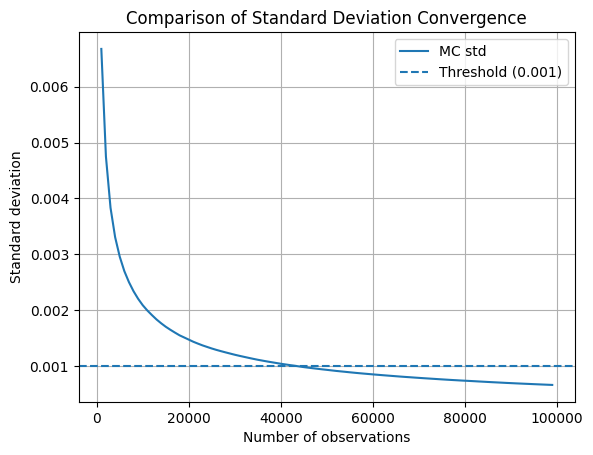

In [7]:
plot_q_2(std_dict, N, step)

From the simulation, we observe that the standard error decreases as the number of samples $N$ increases, consistent with the theoretical rate
$$
\text{SE} \propto \frac{1}{\sqrt{N}}.
$$

From the plot, the standard error drops below the required threshold of $0.001$ at approximately
$$
N \approx 43{,}000.
$$

Thus, at least **43,000 samples** are required to achieve a $1\sigma$ error of at most $0.001$.

The curve shows a rapid decrease in error initially, followed by diminishing returns as $N$ becomes large. This behaviour is characteristic of Monte Carlo methods, where reducing error further requires disproportionately more samples.

# 2.2

Importance sampling can be used to reduce the variance of the original MC estimator. Importance sampling generates a sample from a different distribution than the original and then accounts for this by importance weights. 

It is defined as $f,g,h: \R^d\rightarrow \R$ where $f$ and $g$ are density functions that satisfy $f(x)>0\Rightarrow g(x)>0, \quad \forall x\in \R^d$ and $h$ is a function. The importance sampling estimator of 
$$
\mu_{IS_{n}}=\frac{1}{n}\sum_{i=1}^n h(Z_i)\frac{g(Z_i)}{f(Z_i)}
$$
where $X_1,...,X_n$ are i.i.d. random variables from density $f$. $w(Z_i)=\frac{f(Z_i)}{g(Z_i)}$ is refereed to as the importance weight.

$g(x)=1$ as it is the density function for a uniform variable on $[0,1]$, while $h(x)=\sin(\pi x(1-x))$. 

We therefore need to find $f(z)$ from which we can sample $Z$ from. As $X\sim \mathcal{U}(0,1)$, $X\in[0,1]$. Another distribution on the same domain is the beta distribution with the density
$$
f_Z(z) = \frac{z^{\alpha-1}(1-z)^{\beta-1}}{B(\alpha,\beta)}.
$$
Where $B(\alpha,\beta)=\frac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha + \beta)}$ and $\Gamma$ is the gamma function. By picking $\alpha=\beta=2$, $f_Z(z) = 6z(1-z)$, which highly resembles the inner function of $h(X)$. This $g_Z(z)$ satisfies $g(x)>0\Rightarrow f(x)>0, \quad \forall x\in [0,1]$. 

We can therefore easily efficiently sample $Z\sim B(2,2)$ and estimate $\mu_{IS_{n}}$

To minimize the noise from random samples, we only draw one time and extend the index.

In [8]:
def f_fct(Z):
    return 6*Z*(1-Z)
# draw from beta-distribution now
Z = rng.beta(2,2,size=N)
I_is = g_fct(Z)/f_fct(Z)
step = int(N/1000)
x_axis = list(range(step,N,step))
std_list_1 = []
std_list_2 = []
for i in x_axis:
    std_list_1.append(MC_est(trans[:i])[1])
    std_list_2.append(MC_est(I_is[:i])[1])

std_dict = {}
std_dict['MC std'] = np.array(std_list_1)
std_dict['Importance Sampling std'] = np.array(std_list_2)


We need at least 300 observations for method 2 to reach std < 0.001


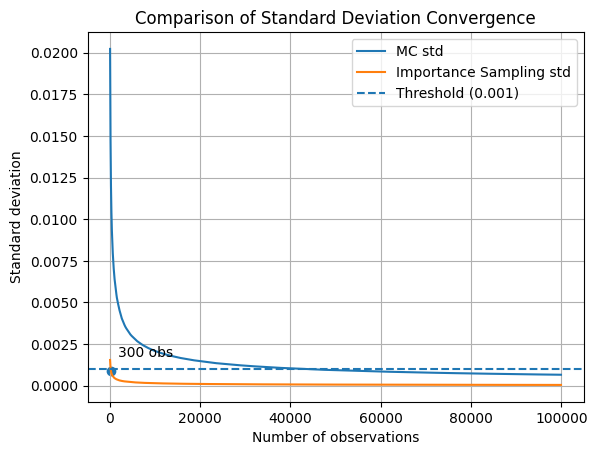

In [9]:
plot_q_2(std_dict, N, step)

From the plot, we observe that the standard error decreases much more rapidly compared to standard Monte Carlo.

The required accuracy of $0.001$ is achieved at approximately
$$
N \approx 300.
$$

Thus, only **around 300 samples** are needed when using importance sampling, compared to approximately $43{,}000$ samples for standard Monte Carlo.

The estimated integral stabilises quickly, and the variance is significantly smaller across all sample sizes.

The improvement occurs because the proposal distribution
$$
f_Z(x) = 6x(1-x)
$$
closely matches the shape of the integrand, concentrating samples near $x = 0.5$, where $\sin(\pi x(1-x))$ is largest.

As a result, the variance of the estimator is greatly reduced, leading to much faster convergence.

In contrast, uniform sampling wastes many samples in regions where the integrand is small, making it inefficient.
